In [1]:
# ============================================================
# FIFA World Cup 2026
# End-to-End Classification Project
# ============================================================

# ==========================
# 1. Import Libraries
# ==========================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Optional XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except:
    XGBOOST_AVAILABLE = False


# ============================================================
# 2. Load Dataset
# ============================================================

DATA_PATH = r"C:\Users\GeoComputer\Documents\ML_PROJECT\machine-learning-deployment-demo\ML_PROJECT_3\fifa_world_cup_2026_player_performance.csv"

df = pd.read_csv(DATA_PATH)

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print(df.head())

print("\nDataset Shape:")
print(df.shape)
print("\nDataset Info:")
print(df.info())
print(df.head())    

Dataset Loaded Successfully
  player_id       player_name  age nationality   team  jersey_number  \
0    P00055        Rodri Fati   26     Spanish  Spain              3   
1    P00070   Ansu Le Normand   19     Spanish  Spain             18   
2    P00066        Gavi Ramos   18     Spanish  Spain             14   
3    P00073     Pedro Cubarsi   20     Spanish  Spain             21   
4    P00059  Alvaro Oyarzabal   23     Spanish  Spain              7   

     position  height_cm  weight_kg preferred_foot  ... possession_impact  \
0  Goalkeeper        195         75           Left  ...               1.1   
1  Midfielder        178         75          Right  ...               3.5   
2  Midfielder        177         72           Left  ...              15.3   
3     Forward        182         74          Right  ...               1.2   
4    Defender        191         81           Left  ...               6.2   

   pressure_resistance creativity_score consistency_score  \
0              

In [2]:
# ============================================================
# 3. Data Understanding
# ============================================================

print("\n")
print("="*60)
print("Dataset Information")
print("="*60)

print(df.info())

print("\nFirst 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nColumn Names")
print(df.columns.tolist())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nStatistical Summary")
print(df.describe(include="all"))

# ============================================================
# Target Column
# ============================================================

TARGET_COLUMN = "match_result"

print("\nTarget Column:")
print(TARGET_COLUMN)

print("\nTarget Distribution")
print(df[TARGET_COLUMN].value_counts())

print("\nTarget Percentage")

print(
    round(
        df[TARGET_COLUMN].value_counts(normalize=True) * 100,
        2
    )
)



Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  str    
 1   player_name               54600 non-null  str    
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  str    
 4   team                      54600 non-null  str    
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  str    
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  str    
 10  club_name                 54600 non-null  str    
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  str    
 13  match_date                54600 non-null  str    


In [3]:
# ============================================================
# Remove Duplicate Rows
# ============================================================

before = len(df)

df = df.drop_duplicates()

after = len(df)

print("\nRemoved Duplicate Rows:", before - after)


Removed Duplicate Rows: 0


In [4]:
# ============================================================
# Features and Target
# ============================================================

X = df.drop(columns=[TARGET_COLUMN])

y = df[TARGET_COLUMN]

print("\nFeature Shape:", X.shape)
print("Target Shape :", y.shape)


Feature Shape: (54600, 74)
Target Shape : (54600,)


In [5]:
# ============================================================
# Detect Column Types
# ============================================================

numeric_features = X.select_dtypes(
    include=[
        "int64",
        "float64"
    ]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns.tolist()

print("\nNumeric Features")

print(numeric_features)

print("\nCategorical Features")

print(categorical_features)


Numeric Features
['age', 'jersey_number', 'height_cm', 'weight_kg', 'market_value_eur', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations', 'stamina_score', 'player_rating', 'performance_score', 'offensive_contribution', 'defensive_contribution', 'possession_impact', 'pressure_resistance', 'creativity_score', 'consistency_score', 'clutch_performance_score', 'total_goals

In [6]:
# ============================================================
# Numerical Pipeline
# ============================================================

numeric_transformer = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )

        ),

        (
            "scaler",

            StandardScaler()

        )

    ]

)

# ============================================================
# Categorical Pipeline
# ============================================================

categorical_transformer = Pipeline(

    steps=[

        (

            "imputer",

            SimpleImputer(
                strategy="most_frequent"
            )

        ),

        (

            "encoder",

            OneHotEncoder(
                handle_unknown="ignore"
            )

        )

    ]

)

# ============================================================
# Combine Both Pipelines
# ============================================================

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_transformer,
            numeric_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )

    ]

)

In [7]:
# ============================================================
# 7. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("Train-Test Split Completed")
print("="*60)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Train-Test Split Completed
Training Samples : (43680, 74)
Testing Samples  : (10920, 74)


In [8]:
# ============================================================
# 8. Define Models
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(),
  
    "Random Forest": RandomForestClassifier(),
   
}

In [9]:
# ============================================================
# 9. Train Models
# ============================================================

results = []

trained_models = {}

for model_name, model in models.items():

    print("\n" + "="*60)
    print("Training :", model_name)
    print("="*60)

    pipeline = Pipeline(

        steps=[

            ("preprocessor", preprocessor),

            ("classifier", model)

        ]

    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    cv_score = cross_val_score(

        pipeline,

        X,

        y,

        cv=5,

        scoring="accuracy"

    ).mean()

    trained_models[model_name] = pipeline

    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "Cross Validation": cv_score

    })

    print("Accuracy :", round(accuracy,4))

    print("Precision:", round(precision,4))

    print("Recall   :", round(recall,4))

    print("F1 Score :", round(f1,4))

    print("CV Score :", round(cv_score,4))


Training : Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
CV Score : 1.0

Training : Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
CV Score : 0.8882


In [10]:
# ============================================================
# 10. Model Comparison
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(

    by="Accuracy",

    ascending=False

)

print("\n")
print("="*60)
print("Model Comparison")
print("="*60)

print(results_df)

print("\nBest Model")

print(results_df.iloc[0])



Model Comparison
                 Model  Accuracy  Precision  Recall  F1 Score  \
0  Logistic Regression       1.0        1.0     1.0       1.0   
1        Random Forest       1.0        1.0     1.0       1.0   

   Cross Validation  
0          1.000000  
1          0.888223  

Best Model
Model               Logistic Regression
Accuracy                            1.0
Precision                           1.0
Recall                              1.0
F1 Score                            1.0
Cross Validation                    1.0
Name: 0, dtype: object


In [11]:
# ============================================================
# 11. Select Best Model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("\n")
print("="*60)

print("Best Model Selected")

print("="*60)

print(best_model_name)



Best Model Selected
Logistic Regression


In [12]:
# ============================================================
# 12. Evaluate Best Model
# ============================================================

print("=" * 60)
print(f"Evaluating Best Model: {best_model_name}")
print("=" * 60)

# Predictions
y_pred = best_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Evaluating Best Model: Logistic Regression
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [13]:
# ============================================================
# Classification Report
# ============================================================

print("\nClassification Report\n")

print(

    classification_report(

        y_test,

        y_pred

    )

)


Classification Report

              precision    recall  f1-score   support

           D       1.00      1.00      1.00      2870
           L       1.00      1.00      1.00      4025
           W       1.00      1.00      1.00      4025

    accuracy                           1.00     10920
   macro avg       1.00      1.00      1.00     10920
weighted avg       1.00      1.00      1.00     10920




Confusion Matrix

[[2870    0    0]
 [   0 4025    0]
 [   0    0 4025]]


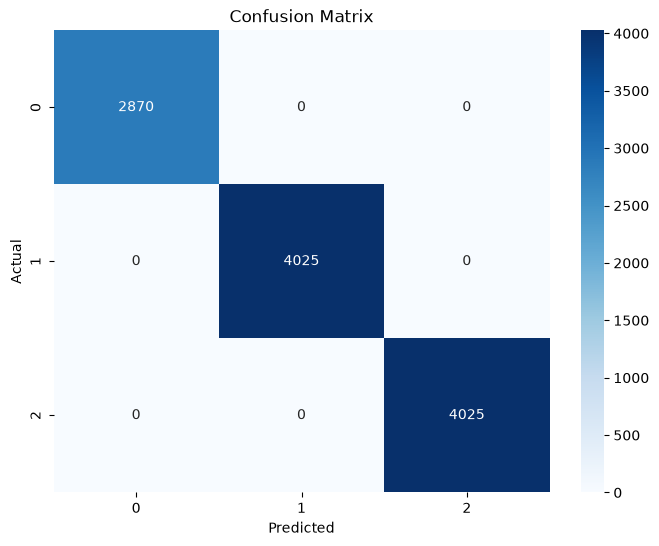

In [14]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(

    y_test,

    y_pred

)

print("\nConfusion Matrix\n")

print(cm)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [17]:
MODEL_FOLDER = "saved_model"
os.makedirs(MODEL_FOLDER, exist_ok=True)

MODEL_PATH = os.path.join(
    MODEL_FOLDER,
    "best_model.pkl"
)

joblib.dump(best_model, MODEL_PATH)

print("Model saved successfully!")
print(MODEL_PATH)

Model saved successfully!
saved_model\best_model.pkl


In [18]:
loaded_model = joblib.load(MODEL_PATH)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [19]:
sample = X.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Prediction:")
print(prediction)

Prediction:
['W']


In [20]:
if hasattr(loaded_model, "predict_proba"):

    probabilities = loaded_model.predict_proba(sample)

    print("Prediction Probabilities:")
    print(probabilities)

Prediction Probabilities:
[[2.22453541e-03 2.75507990e-15 9.97775465e-01]]
